# Image-Level EDA
The bias matching process applied in the previous metadata EDA notebook tells us that the bias matching can be applied to reduce the bias in the dataset. However, it is also important to perform an image-level EDA to understand the distribution of images and their characteristics.

Crucially, this notebook combines multiple per source manifests in `data/interim` (produced by `scripts/build_manifest.py`) into a single combined manifest (`data/interim/manifest_final.parquet`) with paths pointing to the final, model-ready image folders under `data/processed/`, allowing for an overall image analysis. Train/val/test splits are allocated here.

The pipeline this notebook follows is as follows:


```text
per-source manifests (data/interim/*.parquet)
        |
        v
combine_manifests()          -- into one DataFrame standardized to canonical columns
        |
        v
drop is_corrupt rows          -- ignored going forward
        |
        v
assign_group_ids()             -- cross-source near-duplicate clustering (banded LSH)
        |
        v
apply_matching()                -- bias-match real GenImage images (size + JPEG QF)
        |
        v
assign_full_splits()           -- group-aware GenImage split + fixed lookup for
                                   coco / ntire / raise
        |
        v
assert_no_leakage()             -- hard stop if any group/hash spans two splits
        |
        v
save data/interim/manifest_final.parquet
        |
        v
build_processed_dataset()      -- resize + re-encode every surviving image
        |
        v
data/processed/<split>/<ai|human>/<sha256>.jpg
        +
data/processed/manifest.parquet

### 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

## Standard Libraries
from pathlib import Path
import numpy as np
import pandas as pd
import yaml

## Project module imports
from ai_detector.data.selection import(
    SubsetConfig, combine_manifests, assign_group_ids, apply_matching, assign_full_splits, 
    normalize_columns, shortcut_probe)
from ai_detector.data.manifest import(assert_no_leakage, LeakageError)
from ai_detector.data import viz
from ai_detector.preprocessing.image_ops import PreprocessConfig, build_processed_dataset
from ai_detector.data.integrity import near_duplicate_pairs

## Path setup
PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "data"
INTERIM = DATA / "interim"
PROCESSED = DATA / "processed"
RAW = DATA / "raw"
CONFIG_PATH = PROJECT_ROOT / "configs" / "data" / "subset_v1.yaml"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## Preprocessing and data splitting will draw from a yaml file in configs/data
cfg = SubsetConfig.from_yaml(CONFIG_PATH)
raw_cfg = yaml.safe_load(CONFIG_PATH.read_text())
preprocess_cfg = PreprocessConfig.from_yaml_dict(raw_cfg.get("preprocessing", {}))

print(cfg)
print(preprocess_cfg)

SubsetConfig(name='subset_v1', seed=42, real_generator_token='nature', train_generators=['stable_diffusion_v_1_4', 'stable_diffusion_v_1_5', 'glide', 'adm', 'vqdm'], ood_generators=['midjourney', 'wukong', 'biggan'], min_side=450, max_side=550, jpeg_qf=98, jpeg_qf_tolerance=2, val_fraction=0.1, test_in_dist_fraction=0.1, pilot_n_per_stratum=60)
PreprocessConfig(image_size=512, jpeg_qf=98, resample=<Resampling.LANCZOS: 1>)


### 1. Load and combine per-source manifests
Draws from the per-source manifests stored in `data/interim`

In [2]:
manifest_paths = sorted(INTERIM.glob("manifest_*.parquet"))
print(f"Found {len(manifest_paths)} manifest files:")
for p in manifest_paths:
    print(" -", p.name)

df = combine_manifests(manifest_paths)
print(f"\nCombined manifest: {len(df):,} rows, {df['source'].nunique()} sources")
display(df.groupby(["source", "label"]).size().unstack(fill_value=0))

Found 4 manifest files:
 - manifest_coco.parquet
 - manifest_ntire.parquet
 - manifest_raise.parquet
 - manifest_tiny_genimage.parquet

Combined manifest: 90,300 rows, 4 sources


label,0,1
source,,
coco,5000,0
ntire,17982,32018
raise,300,0
tiny_genimage,17500,17500


The combined manifests is sampled below:

In [3]:
display(df.sample(7))
print(df["is_corrupt"].value_counts())

,path,source,sha256,phash,label,generator,split,content_class,group_id,width,height,file_format,file_size_bytes,jpeg_qf,mode,is_corrupt,error
30205,ntire/shard_0/images/80424ef035a1b82bfa3b.jpg,ntire,9222740ffdda64f5f5fcd822d0b6df3d4fc75143a32b90...,2534d227cdd816ab,1,mixed,test_wild,None,None,1024,1024,JPEG,249288,95,RGB,False,None
1326,coco/val2017/000000155451.jpg,coco,d53c8637732ca8e9542fb324cba5bf8224b5816d0bdc86...,1531ec9e6952f05a,0,real,test_ood_real,None,None,640,480,JPEG,113632,91,RGB,False,None
53022,ntire/shard_0/images/f5afa21ceb6e87c54a38.jpg,ntire,2d9b1632c46117a49092034e2e3b9b28a862b1770981c6...,3d0e84d0f4edc136,0,mixed,test_wild,None,None,736,1120,JPEG,191056,95,RGB,False,None
47971,ntire/shard_0/images/db978bff8f49615efec8.jpg,ntire,b7c2309efc3f73ad5e6ba08385f1c9c3f0b9adbe7d4af9...,15edca25fc1a29c2,0,mixed,test_wild,None,None,800,800,JPEG,205896,95,RGB,False,None
58323,tiny_genimage/imagenet_ai_0419_biggan/train/na...,tiny_genimage,5aad07414b549a9be5524c46558828ac84da92f2f94329...,1fbb78cab1468530,0,nature,train,None,None,494,500,JPEG,244981,96.0,RGB,False,None
70501,tiny_genimage/imagenet_ai_0424_wukong/train/ai...,tiny_genimage,69e8b747e6eb247009f55748e8094de196567053431846...,43b1bbc630cccc39,1,wukong,train,None,None,512,512,PNG,518028,NaN,RGB,False,None
70546,tiny_genimage/imagenet_ai_0424_wukong/train/ai...,tiny_genimage,e461720d7612aa36d05221e6af48fd9956a41046b175a1...,2eced3f184f01961,1,wukong,train,None,None,512,512,PNG,492078,NaN,RGB,False,None


is_corrupt
False    90300
Name: count, dtype: int64


### 2. Drop corrupt image rows
In the event corrupt images are present. These are flagged by `probe_decodability()` when the individual source-specific manifests were created. They lack a usable `phash` and therefore cannot be preprocessed/grouped/split, therefore they must be removed.

In [4]:
n_before= len(df)
corrupt= df[df["is_corrupt"]]

if len(corrupt):
    display(corrupt[["path", "source", "error"]].head(10))
df = df[~df["is_corrupt"]].reset_index(drop=True)
print(f"Dropped {n_before - len(df)} corrupt rows ({(n_before - len(df)) / n_before:.2%})")
print(f"Remaining: {len(df):,} rows")

Dropped 0 corrupt rows (0.00%)
Remaining: 90,300 rows


### 3. Cross-source Near-duplicate clustering
We initially implemented a Banded LSH + UnionFind (`integrity.py`) pipeline to group similar images within a particular source. This time, we apply the same grouping strategy across the entire combined manifest. 

Rather check for similar images on a pairwise basis that may result in potentially billions of image pair combinations, the Banded LSH approach breaks these potential comparisons into a smaller candidate set.

We first do a surface-level check for duplicates (`sha256`) and near duplicates (`phash`) distribution.

In [5]:
## Examining the sha256 distributions 
df['sha256'].value_counts()

sha256
094963924102c9470b68219862f16bae78c847f4534ce96bf4f4b3e61191d2aa    4
c140982b6f978880be0eb04d6718bb1f2ae272c00cf127cced8d0c9568f9e399    4
bbfbc95dda4d386341d61200181d1f0b0c62febfb0e32930c99529761952c01c    3
5c895dbc3d5bcec46b4d07029b54a092d7206be6d815776e8839129e021c00a3    2
0febf7fe422dde2328f71126ad53b20ad373838b9c46f6401a61ee44813b842a    2
                                                                   ..
5aea521e9325798aa96f23992b0ee3fbdd9c709d88403db8fafa08624c56c20a    1
5be09f79b0aaa897be034c919514ccad68aceda1531ac9d534c0be82a2126ddb    1
c5db0cbc5d790fb0c4ec9e39892b31fa201f619c525cdfa1be84a1952a56e56b    1
2e1ccc20d38d5707e166a518b73fd3ba459f0118dbc3512eaccd9de589c73815    1
8da8f8d03681ad32788eeb3afcc29d59b3e9fab46d7acb1ded8f3bc6660e3415    1
Name: count, Length: 90287, dtype: int64

Only 13 duplicates within the entire dataset. Duplicated images will have to be dropped.

In [6]:
# Drop duplicate images based on their SHA-256 hash
# First occurence is retained
duplicate_mask = df["sha256"].duplicated(keep="first")
n_duplicates = int(duplicate_mask.sum())

if n_duplicates:
    display(df.loc[duplicate_mask, ["path", "source", "sha256"]])

df = df.loc[~duplicate_mask].reset_index(drop=True)

print(f"Dropped {n_duplicates:,} duplicate images")
print(f"Remaining: {len(df):,} images")

,path,source,sha256
17853,ntire/shard_0/images/42575e4ef379bcf42a92.jpg,ntire,094963924102c9470b68219862f16bae78c847f4534ce9...
19180,ntire/shard_0/images/48d592d2a89e334c913b.jpg,ntire,094963924102c9470b68219862f16bae78c847f4534ce9...
24095,ntire/shard_0/images/61962119cb16b5333dd1.jpg,ntire,c140982b6f978880be0eb04d6718bb1f2ae272c00cf127...
26955,ntire/shard_0/images/701038a898272876e7a3.jpg,ntire,094963924102c9470b68219862f16bae78c847f4534ce9...
30304,ntire/shard_0/images/80c6c0b23fcb5df2b034.jpg,ntire,c140982b6f978880be0eb04d6718bb1f2ae272c00cf127...
39840,ntire/shard_0/images/b1a907331d529181fffb.jpg,ntire,bbfbc95dda4d386341d61200181d1f0b0c62febfb0e329...
41813,ntire/shard_0/images/bbe7f9478241480c6e02.jpg,ntire,c140982b6f978880be0eb04d6718bb1f2ae272c00cf127...
43131,ntire/shard_0/images/c2d209855448317f7490.jpg,ntire,bbfbc95dda4d386341d61200181d1f0b0c62febfb0e329...
44929,ntire/shard_0/images/cc16dff402393d3d234f.jpg,ntire,5c895dbc3d5bcec46b4d07029b54a092d7206be6d81577...
45164,ntire/shard_0/images/cd53df80c24160e445ab.jpg,ntire,d44e9f82223b4bbcc0f726d211999a1dee747360ede310...


Dropped 13 duplicate images
Remaining: 90,287 images


In [7]:
## Examining the phash distributions 
df['phash'].value_counts()

phash
0000000000000000    17
42ca4e4873515ddd     2
23dc954bdb1c2561     2
15a55e1ba568c137     2
12926d6d92926d6d     2
                    ..
33c3c49cb9e3c622     1
731bca63e1809f0e     1
65969b0b7ce00667     1
405337706dcdc98d     1
422fe4cce2322767     1
Name: count, Length: 90267, dtype: int64

In [8]:
dedup_cfg= raw_cfg.get("dedup", {}) # Get grouping parameters from yaml file
df= assign_group_ids(df, **dedup_cfg)
    # max_distance and n_bands are unpacked from the yaml config to kwargs
    # If an error is thrown here, ensure paramater values have been added to the yaml file

group_sizes= df.groupby("group_id").size()
print(f"{df["group_id"].nunique():,} distinct groups from {len(df)} images")
print(f"Largest cluster size: {group_sizes.max()}")
display(group_sizes.value_counts().sort_index().head(10))

90,253 distinct groups from 90287 images
Largest cluster size: 17


1     90236
2        14
3         2
17        1
Name: count, dtype: int64

Low duplicate rate is expected as the images are from independent sources. This is good. The cluster of 29 images is however suspicious. These probably indicate near-uniform images (e.g.- flat sky, solid black/white frames, etc.) We will investigate them visually and drop those that provide no visual distinctions.

C:\Users\ProBook\AppData\Local\Temp\ipykernel_6216\3386863178.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


No near-duplicate pairs found in this sample at the current threshold for image source **coco**
No near-duplicate pairs found in this sample at the current threshold for image source **raise**


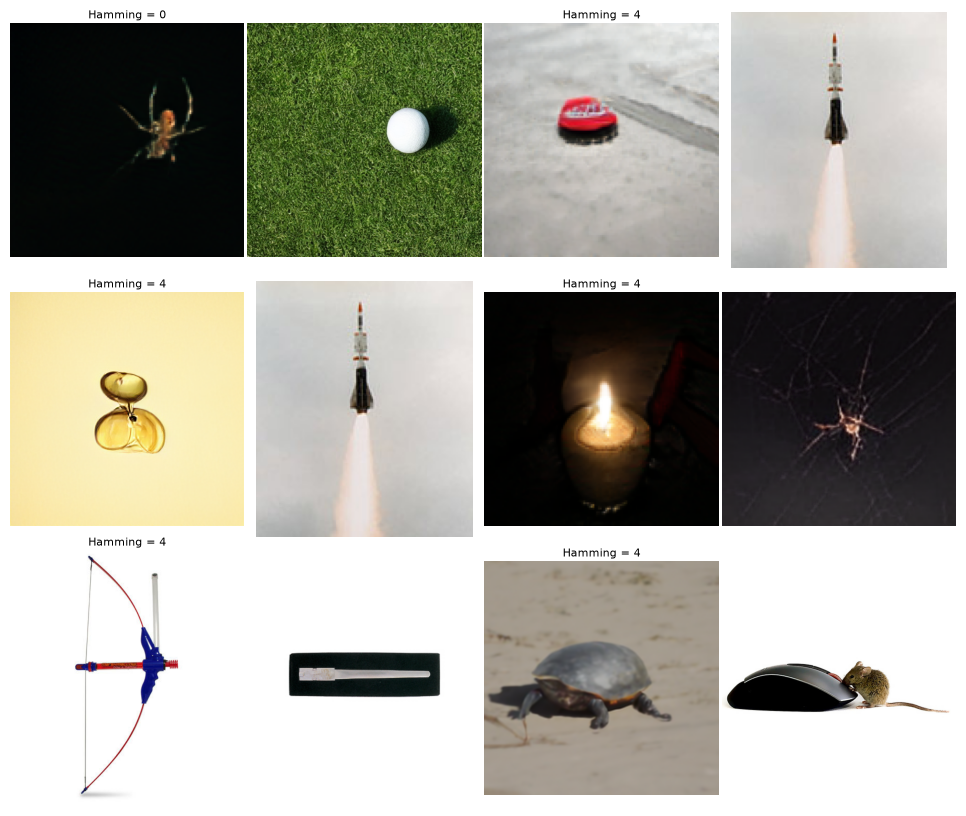

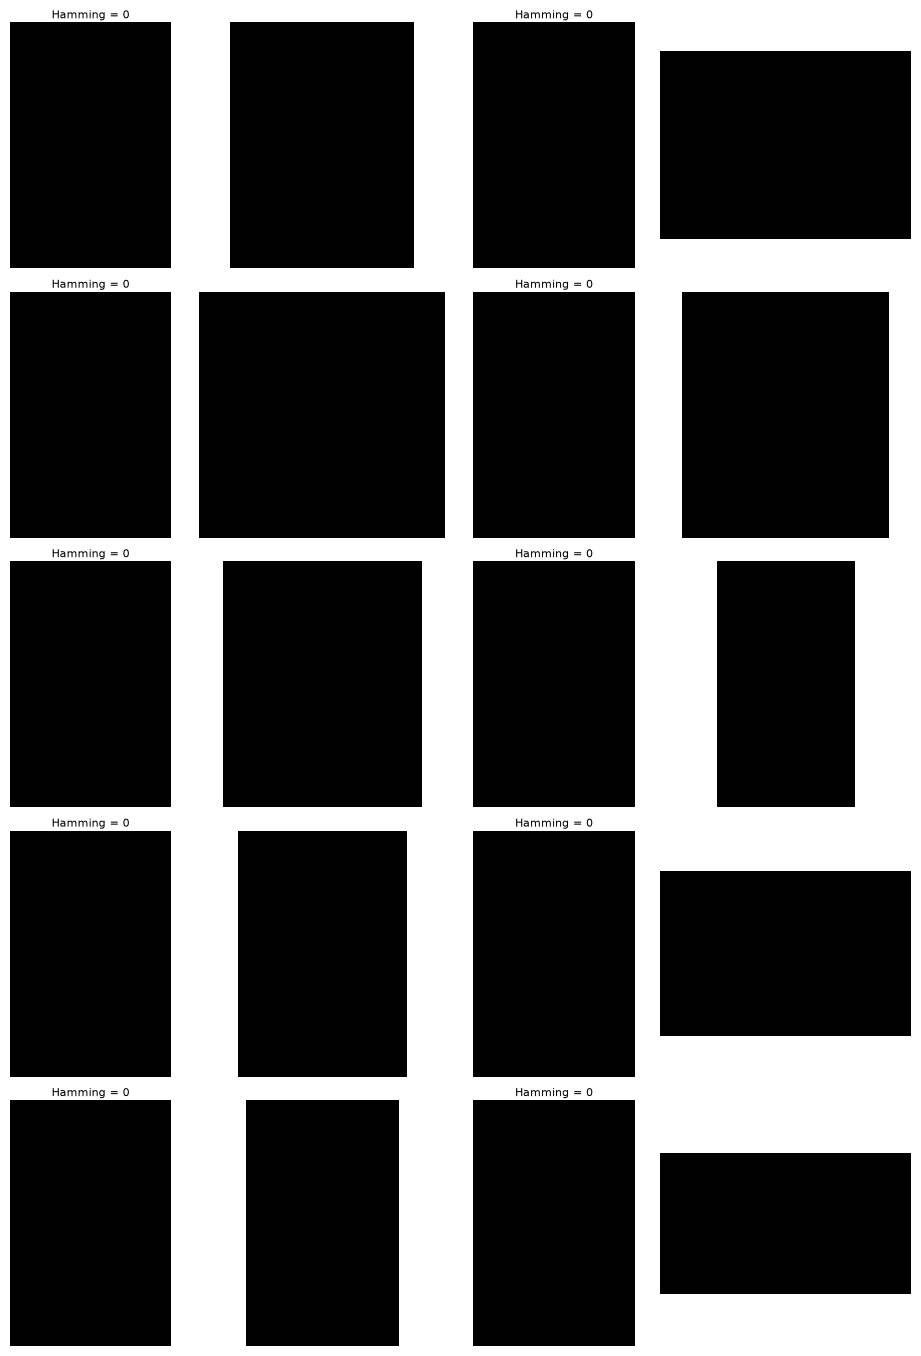

In [9]:
## Visual inspection of image pairs per source
sources= ["tiny_genimage", "ntire", "coco", "raise"]

for sc in sources:
    sample_mask = df["source"] == sc
    sample = df[sample_mask].reset_index(drop=True)
    pairs = near_duplicate_pairs(sample["phash"].tolist(), **dedup_cfg) 
      # Ensure dedup parameters are updated in subset_v1.config
    pairs_sorted = sorted(pairs, key=lambda t: t[2])  
      # Sorting via hamming distance in index 2 of the returned tuple
    path_pairs = [
        (RAW / str(sample.loc[a, "path"]), RAW / str(sample.loc[b, "path"]), d)
        for a, b, d in pairs_sorted
    ]
    if path_pairs:
        fig = viz.pair_grid(path_pairs, max_pairs= 10)
        fig.show()
    else:
        print(f"No near-duplicate pairs found in this sample at the current threshold for image source **{sc}**")

Genuine image duplicates as well as the suspicious pure-black image cluster of 29 images comes from `ntire` image source. These pure-black images can be dropped from the dataset.

In [10]:
zero_phash = df["phash"].astype("string").str.lower().eq("0000000000000000")
n_zero_phash = int(zero_phash.sum())

if n_zero_phash:
    display(df.loc[zero_phash, ["path", "source", "phash"]].sample(10))

df = df.loc[~zero_phash].reset_index(drop=True)

print(f"Dropped {n_zero_phash:,} images with pHash 0000000000000000")
print(f"Remaining: {len(df):,} images")

display(df.head())

,path,source,phash
11601,ntire/shard_0/images/21db18c26b96888580dd.jpg,ntire,0000000000000000
22620,ntire/shard_0/images/5a49f408b86948e62fa7.jpg,ntire,0000000000000000
53183,ntire/shard_0/images/f69b33c488d7d3f36d6d.jpg,ntire,0000000000000000
23750,ntire/shard_0/images/5fc4a9660601bfc5ef69.jpg,ntire,0000000000000000
5602,ntire/shard_0/images/031f645d9fc2d62084c0.jpg,ntire,0000000000000000
21769,ntire/shard_0/images/5600fe262fc9aaebd231.jpg,ntire,0000000000000000
35213,ntire/shard_0/images/99f7a6f69180dff33630.jpg,ntire,0000000000000000
32796,ntire/shard_0/images/8dbf1d81af65c931bcc8.jpg,ntire,0000000000000000
12229,ntire/shard_0/images/24de3d57839bbf61f952.jpg,ntire,0000000000000000
42833,ntire/shard_0/images/c151e485e965a1c724a6.jpg,ntire,0000000000000000


Dropped 17 images with pHash 0000000000000000
Remaining: 90,270 images


,path,source,sha256,phash,label,generator,split,content_class,group_id,width,height,file_format,file_size_bytes,jpeg_qf,mode,is_corrupt,error
0,coco/val2017/000000000139.jpg,coco,ffe0f0cec3b2e27aab1967229cdf0a0d7751dcdd580032...,15d3f8748359f805,0,real,test_ood_real,None,0,640,426,JPEG,161811,96,RGB,False,None
1,coco/val2017/000000000285.jpg,coco,f3a2974ce3686332609124c70e3e6a2e3aca43fccf1cd1...,2dc0793ab234790f,0,real,test_ood_real,None,1,586,640,JPEG,335861,96,RGB,False,None
2,coco/val2017/000000000632.jpg,coco,a4cd7f45ac1ce27eaafb254b23af7c0b18a064be08870c...,1dc9a26627d66233,0,real,test_ood_real,None,2,640,483,JPEG,155667,91,RGB,False,None
3,coco/val2017/000000000724.jpg,coco,5c0e559c75d3969c8e3e297b61f61063f78045c9d4802b...,2633bc3ac763451c,0,real,test_ood_real,None,3,375,500,JPEG,130107,96,RGB,False,None
4,coco/val2017/000000000776.jpg,coco,1dd31e9059c491992be2f562624eb4093e17aee08b4f7b...,6ad48d56840b56bd,0,real,test_ood_real,None,4,428,640,JPEG,176410,91,RGB,False,None


We can then inspect genuine image duplicates across the combined dataset.

C:\Users\ProBook\AppData\Local\Temp\ipykernel_6216\2665772210.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


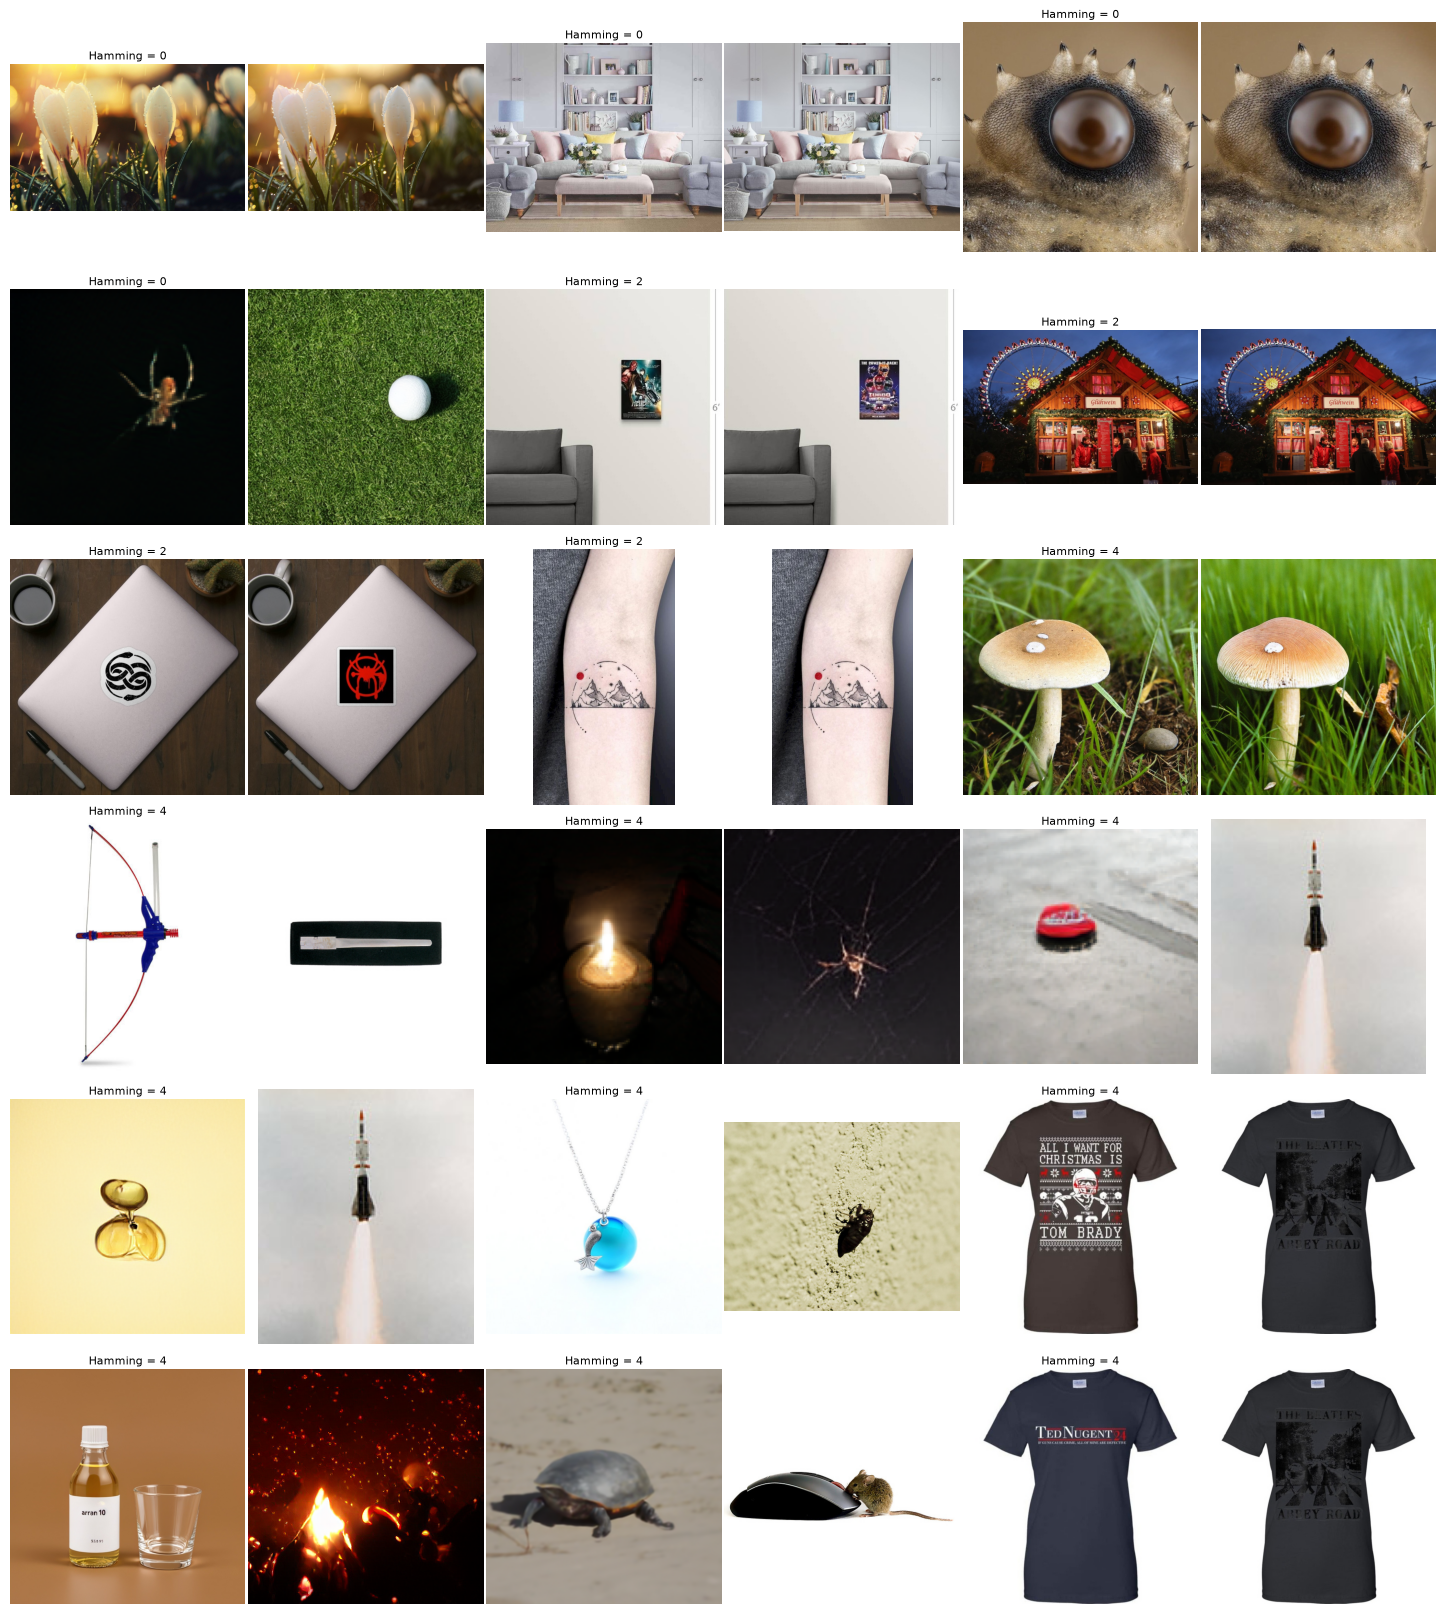

In [11]:
## Visual inspection of image pairs for the combined dataset
pairs = near_duplicate_pairs(df["phash"].tolist(), **dedup_cfg)
pairs_sorted = sorted(pairs, key=lambda t: t[2])
path_pairs = [
    (RAW / str(df.loc[a, "path"]), RAW / str(df.loc[b, "path"]), d)
    for a, b, d in pairs_sorted
]
if path_pairs:
    fig = viz.pair_grid(path_pairs, max_pairs= 21, ncols= 3)
    fig.show()
else:
    print(f"No near-duplicate pairs found in this sample at the current threshold")

### 4. Data Splitting
We apply a data splitting strategy to split the GenImage images into in-distribution `train`, `val`, `test_in_dist` and out of distribution `test_ood_genimage`. Sets from other image sources such (`test_wild`, `test_ood_real`, `test_ood_real_uncompressed`) were already assigned with images from the respective sources during manifest building.. The GenImage generator splits are specified in `configs/data/subset_v1.yaml`.


| Split | Sources / Generators |
|---|---|
| `train` | stable_diffusion_v_1_4, stable_diffusion_v_1_5, glide, adm, vqdm |
| `test_ood_genimage` | midjourney, wukong, biggan |
| `test_wild` | NTIRE |
| `test_ood_real` | COCO |
| `test_ood_real_uncompressed` | RAISE |

In [12]:
df = assign_full_splits(df, cfg, generator_aliases= 
                        {"imagenet_ai_0419_biggan": "biggan",
                        "imagenet_ai_0419_vqdm": "vqdm",
                        "imagenet_ai_0424_sdv5": "stable_diffusion_v_1_5",
                        "imagenet_ai_0424_wukong": "wukong",
                        "imagenet_ai_0508_adm": "adm",
                        "imagenet_glide": "glide",
                        "imagenet_midjourney": "midjourney",})
display(df.groupby(["source", "split"]).size().unstack(fill_value=0))

split,test_in_dist,test_ood_genimage,test_ood_real,test_ood_real_uncompressed,test_wild,train,val
source,,,,,,,
coco,0,0,5000,0,0,0,0
ntire,0,0,0,0,49971,0,0
raise,0,0,0,300,0,0,0
tiny_genimage,2312,11874,0,0,0,18501,2312


In [21]:
# Count images in each split for every generator
generator_split_counts = pd.crosstab(df["generator"], df["split"])

# Percentage distribution of splits within each generator
generator_split_percentages = (
    generator_split_counts
    .div(generator_split_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

for generator in generator_split_counts.index:
    total = generator_split_counts.loc[generator].sum()
    print(f"{generator} (total: {total})")
    for split in generator_split_counts.columns:
        count = generator_split_counts.loc[generator, split]
        pct = generator_split_percentages.loc[generator, split]
        print(f"  - {split}: {count} ({pct}%)")
    print()


adm (total: 2500)
  - test_in_dist: 264 (10.56%)
  - test_ood_genimage: 0 (0.0%)
  - test_ood_real: 0 (0.0%)
  - test_ood_real_uncompressed: 0 (0.0%)
  - test_wild: 0 (0.0%)
  - train: 1983 (79.32%)
  - val: 253 (10.12%)

biggan (total: 2500)
  - test_in_dist: 0 (0.0%)
  - test_ood_genimage: 2500 (100.0%)
  - test_ood_real: 0 (0.0%)
  - test_ood_real_uncompressed: 0 (0.0%)
  - test_wild: 0 (0.0%)
  - train: 0 (0.0%)
  - val: 0 (0.0%)

glide (total: 2500)
  - test_in_dist: 252 (10.08%)
  - test_ood_genimage: 0 (0.0%)
  - test_ood_real: 0 (0.0%)
  - test_ood_real_uncompressed: 0 (0.0%)
  - test_wild: 0 (0.0%)
  - train: 2036 (81.44%)
  - val: 212 (8.48%)

midjourney (total: 2500)
  - test_in_dist: 0 (0.0%)
  - test_ood_genimage: 2500 (100.0%)
  - test_ood_real: 0 (0.0%)
  - test_ood_real_uncompressed: 0 (0.0%)
  - test_wild: 0 (0.0%)
  - train: 0 (0.0%)
  - val: 0 (0.0%)

mixed (total: 49971)
  - test_in_dist: 0 (0.0%)
  - test_ood_genimage: 0 (0.0%)
  - test_ood_real: 0 (0.0%)
  - test_

In [27]:
df.groupby("generator")["jpeg_qf"].value_counts()

generator  jpeg_qf
mixed      95.0       49971
nature     96.0         693
           100.0          6
           97.0           3
           99.0           2
           98.0           1
real       96.0        3540
           91.0        1414
           81.0          46
Name: count, dtype: int64

In [30]:
df["jpeg_qf"].isna().sum()

np.int64(17800)

### Bias-Matching
Bias-matching is a filtering technique that restricts real images to the size dimensions and JPEG QF of AI generated images as a means to eliminate any shortcut signal the model may learn in lieu of image artifacts. This is applied to the intended training set only (GenImage images).

In [22]:
genimage_sources = ("genimage", "tiny_genimage")
is_genimage = df["source"].isin(genimage_sources)

before_counts = df[is_genimage].groupby(df["generator"] == cfg.real_generator_token).size()
matched_genimage = apply_matching(df[is_genimage], cfg)
after_counts = matched_genimage.groupby(matched_genimage["generator"] == cfg.real_generator_token).size()

print("Real images before matching:", int(before_counts.get(True, 0)))
print("Real images after  matching:", int(after_counts.get(True, 0)))
print("AI images unaffected:", int(after_counts.get(False, 0)) == int(before_counts.get(False, 0)))

df = pd.concat([matched_genimage, df[~is_genimage]], ignore_index=False)
print(f"\nManifest size after matching: {len(df):,} rows")

Real images before matching: 17499
Real images after  matching: 705
AI images unaffected: True

Manifest size after matching: 73,476 rows
